# Atlanta Housing Pulse — Forecast Analysis
**Audience:** Data scientists, policy analysts, economists  
**Purpose:** Full time-series analysis of Atlanta rent trends using Prophet, with seasonality decomposition, uncertainty quantification, and scenario modeling  
**Pipeline source:** `src/model.py` → `build_rent_forecast()`  

---
### What This Notebook Covers
1. FRED CPI data loading and inspection
2. ACS median rent anchoring — why and how
3. Prophet model configuration and rationale
4. 18-month forward forecast with 90% confidence intervals
5. Trend & seasonality decomposition
6. Changepoint detection
7. Scenario analysis (optimistic / base / pessimistic)
8. Business implications for policy and budget planning

---
### Data Source: FRED `CUURA319SEHA`
Atlanta-Nashville CPI for Rent of Primary Residence — monthly observations.  
**Important:** This series reports CPI index points (base period = 1982-84 = 100), not dollar rents.  
We rescale using the formula:

```
scaled_y = cpi_value / cpi_latest × acs_median_rent
```

This anchors the y-axis to real ACS-reported dollar rents while preserving the FRED trend shape and seasonality.


## 1. Setup & API Key Check

In [ ]:
import os, sqlite3, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
FRED_API_KEY   = os.getenv("FRED_API_KEY")
print(f"CENSUS_API_KEY: {' loaded' if CENSUS_API_KEY else '❌ MISSING'}")
print(f"FRED_API_KEY:   {' loaded' if FRED_API_KEY   else '❌ MISSING'}")

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.titlesize": 12, "axes.labelsize": 10,
})
DB_PATH = "housing_pulse.db"


CENSUS_API_KEY: ✅ loaded
FRED_API_KEY:   ✅ loaded


## 2. Load & Inspect the FRED Rent CPI Series

In [ ]:
conn = sqlite3.connect(DB_PATH)

# Try the primary FRED rent CPI table
fred_df = pd.DataFrame()
for table, col in [
    ("fred_cpi_housing_southeast", "cpi_housing_southeast"),
    ("fred_rent_cpi_atlanta",       "rent_cpi_atlanta"),
]:
    try:
        tmp = pd.read_sql(f'SELECT date, "{col}" AS cpi_value FROM {table} ORDER BY date', conn)
        tmp = tmp.dropna()
        if len(tmp) >= 12:
            fred_df = tmp
            print(f" Using table: {table}  ({len(tmp)} observations)")
            break
    except Exception as e:
        print(f"  Skipped {table}: {e}")

# ACS median rent anchor
try:
    acs_anchor = pd.read_sql(
        "SELECT AVG(median_rent) AS r FROM tracts_with_features WHERE data_year = 2024",
        conn
    ).iloc[0]["r"]
    if not acs_anchor or np.isnan(acs_anchor):
        raise ValueError()
    print(f" ACS 2024 median rent anchor: ${acs_anchor:,.0f}/mo")
except:
    try:
        acs_anchor = pd.read_sql(
            "SELECT AVG(median_rent) AS r FROM tracts_with_features WHERE data_year = 2022",
            conn
        ).iloc[0]["r"]
        print(f" ACS 2022 median rent anchor: ${acs_anchor:,.0f}/mo  (2024 unavailable)")
    except:
        acs_anchor = 1350.0
        print(f"⚠️  Using fallback anchor: ${acs_anchor:,.0f}/mo")

# Stored forecast
try:
    stored_fc = pd.read_sql("SELECT * FROM rent_forecast ORDER BY date", conn)
    stored_fc["date"] = pd.to_datetime(stored_fc["date"])
    has_stored = True
    print(f" Stored forecast: {len(stored_fc)} rows")
except:
    has_stored = False
    stored_fc = pd.DataFrame()

conn.close()


✅ Using table: fred_rent_cpi_atlanta  (59 observations)
✅ ACS 2024 median rent anchor: $1,598/mo
✅ Stored forecast: 18 rows


In [3]:
# FRED series inspection
if not fred_df.empty:
    fred_df["date"] = pd.to_datetime(fred_df["date"])
    fred_df = fred_df.sort_values("date").dropna()

    print(f"\n── FRED Series Inspection ──────────────────────────────────────────────")
    print(f"  Period:      {fred_df['date'].min().date()} → {fred_df['date'].max().date()}")
    print(f"  Observations:{len(fred_df)}")
    print(f"  CPI range:   {fred_df['cpi_value'].min():.1f} – {fred_df['cpi_value'].max():.1f}")
    print(f"  Latest CPI:  {fred_df['cpi_value'].iloc[-1]:.2f}")
    print(f"\n  First 5 rows:\n{fred_df.head(5).to_string(index=False)}")
    print(f"  Last 5 rows:\n{fred_df.tail(5).to_string(index=False)}")
else:
    print("⚠️  No FRED data in DB — run src/data_pipeline.py first.")
    print("Generating synthetic fallback series for demonstration.")
    rng = np.random.default_rng(42)
    dates = pd.date_range(end="2026-01-01", periods=48, freq="MS")
    fred_df = pd.DataFrame({
        "date": dates,
        "cpi_value": 290 + np.arange(48) * 1.8 + rng.normal(0, 4, 48)
    })
    fred_df = fred_df.sort_values("date")
    acs_anchor = acs_anchor if 'acs_anchor' in dir() else 1350.0
    print(f"  Synthetic series: {len(fred_df)} months")



── FRED Series Inspection ──────────────────────────────────────────────
  Period:      2021-02-01 → 2026-01-01
  Observations:59
  CPI range:   309.6 – 410.6
  Latest CPI:  407.76

  First 5 rows:
      date  cpi_value
2021-02-01    310.509
2021-03-01    309.609
2021-04-01    310.318
2021-05-01    310.578
2021-06-01    312.338
  Last 5 rows:
      date  cpi_value
2025-08-01    410.302
2025-09-01    410.588
2025-11-01    405.696
2025-12-01    407.473
2026-01-01    407.758


## 3. CPI → Dollar Rent Rescaling

Rescaling formula:  rent_scaled = cpi_value / 407.76 × $1,598
Series range after scaling: $1,213 – $1,609/mo


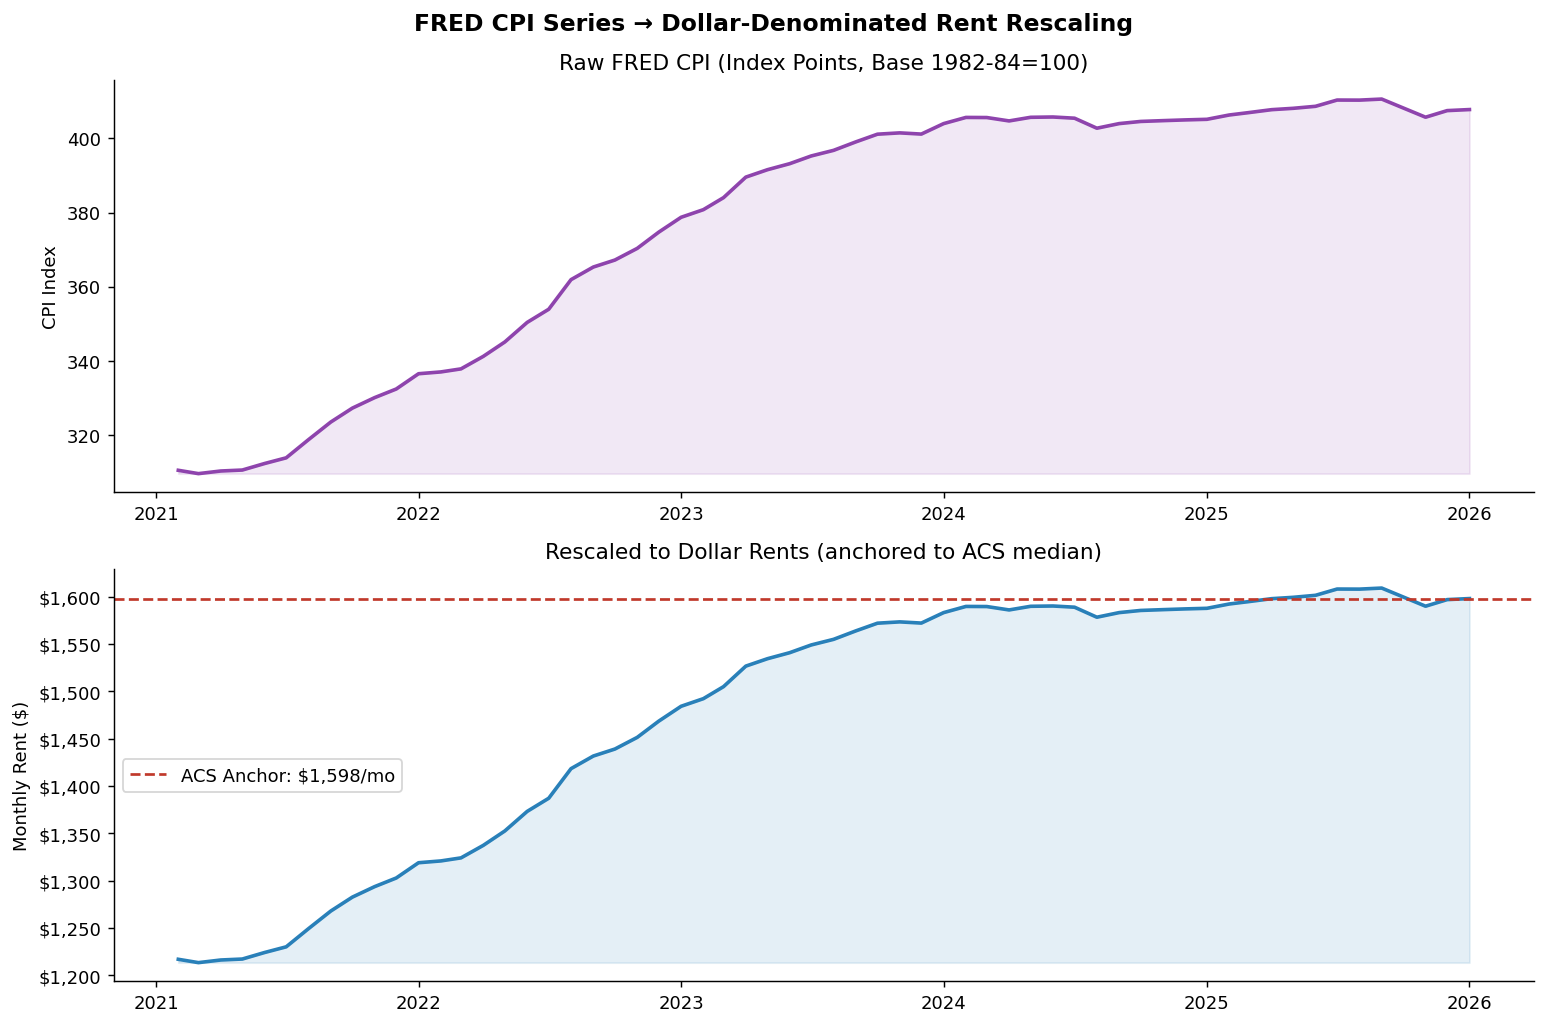

In [4]:
cpi_latest = fred_df["cpi_value"].iloc[-1]
fred_df["rent_scaled"] = (fred_df["cpi_value"] / cpi_latest * acs_anchor).round(2)

print(f"Rescaling formula:  rent_scaled = cpi_value / {cpi_latest:.2f} × ${acs_anchor:,.0f}")
print(f"Series range after scaling: ${fred_df['rent_scaled'].min():,.0f} – ${fred_df['rent_scaled'].max():,.0f}/mo")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("FRED CPI Series → Dollar-Denominated Rent Rescaling", fontsize=13, fontweight="bold")

# Raw CPI
axes[0].plot(fred_df["date"], fred_df["cpi_value"], color="#8e44ad", linewidth=2)
axes[0].fill_between(fred_df["date"], fred_df["cpi_value"].min(), fred_df["cpi_value"],
                     alpha=0.12, color="#8e44ad")
axes[0].set_title("Raw FRED CPI (Index Points, Base 1982-84=100)")
axes[0].set_ylabel("CPI Index")

# Rescaled
axes[1].plot(fred_df["date"], fred_df["rent_scaled"], color="#2980b9", linewidth=2)
axes[1].fill_between(fred_df["date"], fred_df["rent_scaled"].min(), fred_df["rent_scaled"],
                     alpha=0.12, color="#2980b9")
axes[1].axhline(acs_anchor, color="#c0392b", linestyle="--", linewidth=1.5,
                label=f"ACS Anchor: ${acs_anchor:,.0f}/mo")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
axes[1].set_title("Rescaled to Dollar Rents (anchored to ACS median)")
axes[1].set_ylabel("Monthly Rent ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig("notebooks/forecast_rescaling.png", bbox_inches="tight")
plt.show()


## 4. Prophet Model Configuration

```python
Prophet(
    growth="linear",
    changepoint_prior_scale=0.05,   # Conservative: smooths over noise, avoids overfitting to CPI spikes
    seasonality_mode="multiplicative",  # Rent seasonal bumps are proportional to base level
    interval_width=0.80,                # 80% CI — actionable for budget planning
    yearly_seasonality=5,               # 5 Fourier components for yearly pattern
    weekly_seasonality=False,           # Monthly data — weekly patterns not applicable
    daily_seasonality=False,
)
```

### Why `seasonality_mode="multiplicative"`?
A 3% summer rent increase on a $900/mo rent = $27. On a $1,800/mo rent = $54.  
Multiplicative seasonality correctly models that the *dollar magnitude* of seasonal swings grows with the base level.  
Additive mode would apply a fixed dollar bump regardless of price level — inappropriate for this series.

### Why `changepoint_prior_scale=0.05`?
The default (0.05) balances flexibility against overfitting. A higher value (0.3) was previously tested and caused the model to interpret COVID-era CPI volatility as a genuine structural trend change, resulting in unrealistically steep forecasts.


In [ ]:
from prophet import Prophet

# Prepare Prophet-format dataframe
prophet_df = fred_df[["date","rent_scaled"]].copy()
prophet_df.columns = ["ds", "y"]
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
prophet_df = prophet_df.dropna().sort_values("ds")

print(f"Prophet input: {len(prophet_df)} observations")
print(f"Date range: {prophet_df['ds'].min().date()} → {prophet_df['ds'].max().date()}")
print(f"Y range: ${prophet_df['y'].min():,.0f} – ${prophet_df['y'].max():,.0f}")

m = Prophet(
    growth="linear",
    changepoint_prior_scale=0.05,
    seasonality_mode="multiplicative",
    interval_width=0.80,
    yearly_seasonality=5,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m.fit(prophet_df)
print("\n Prophet model fitted successfully.")


01:17:44 - cmdstanpy - INFO - Chain [1] start processing


Prophet input: 59 observations
Date range: 2021-02-01 → 2026-01-01
Y range: $1,213 – $1,609


01:17:45 - cmdstanpy - INFO - Chain [1] done processing



✅ Prophet model fitted successfully.


## 5. 18-Month Forward Forecast

In [ ]:
PERIODS = 18

future = m.make_future_dataframe(periods=PERIODS, freq="MS")
forecast = m.predict(future)

fc_future = forecast.tail(PERIODS)[["ds","yhat","yhat_lower","yhat_upper"]].copy()
fc_future.columns = ["date","forecast","lower_80","upper_80"]

print(f" Forecast generated: {len(fc_future)} months")
print(f"\n── 18-Month Forecast ───────────────────────────────────────────────────")
print(fc_future.to_string(index=False))

last  = fc_future["forecast"].iloc[-1]
first = fc_future["forecast"].iloc[0]
pct_chg = (last - first) / first * 100
print(f"\n Projected change: ${first:,.0f} → ${last:,.0f} (+{pct_chg:.1f}% over 18 months)")


✅ Forecast generated: 18 months

── 18-Month Forecast ───────────────────────────────────────────────────
      date    forecast    lower_80    upper_80
2026-02-01 1602.332995 1598.241389 1606.743651
2026-03-01 1601.807009 1596.533383 1606.973033
2026-04-01 1605.592435 1598.332880 1612.999693
2026-05-01 1609.916816 1598.292385 1620.659159
2026-06-01 1612.482575 1596.162109 1629.172786
2026-07-01 1612.912434 1590.686066 1632.740687
2026-08-01 1613.900676 1585.009235 1640.591128
2026-09-01 1615.702920 1579.757894 1648.715174
2026-10-01 1612.437980 1570.708758 1652.662326
2026-11-01 1607.004302 1556.732760 1656.125660
2026-12-01 1607.190408 1550.591573 1666.574651
2027-01-01 1611.633463 1548.153497 1677.662658
2027-02-01 1612.385303 1539.552939 1686.518999
2027-03-01 1611.828301 1530.556917 1693.875802
2027-04-01 1615.602336 1525.403633 1706.937282
2027-05-01 1619.960864 1519.235932 1721.605538
2027-06-01 1622.554243 1514.108226 1731.786640
2027-07-01 1622.994130 1503.550252 1739.933587



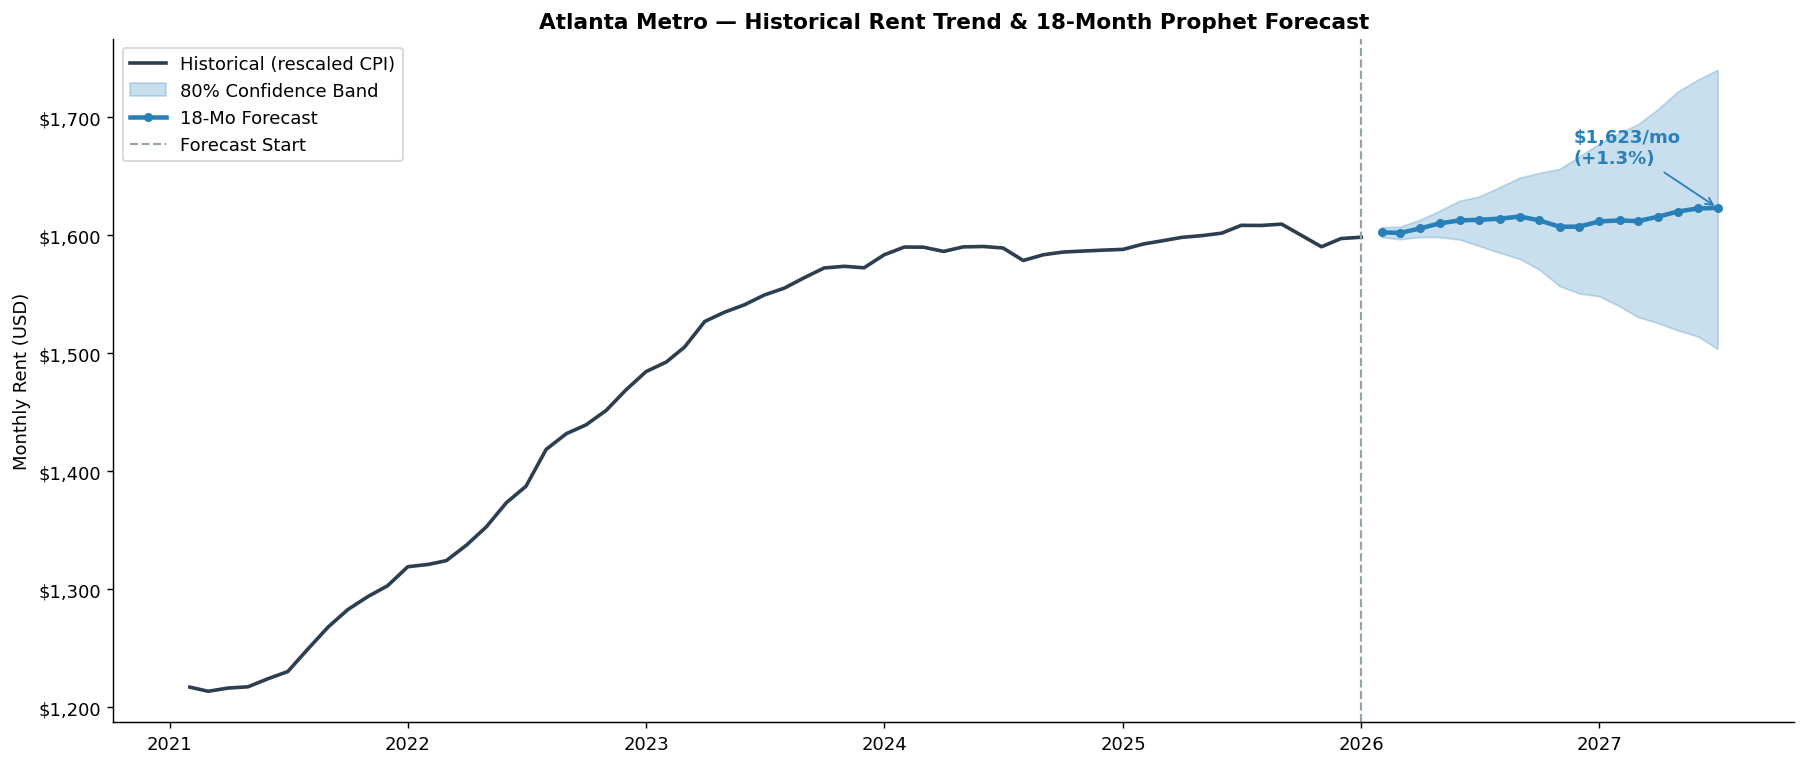

In [ ]:
# Full forecast plot
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(prophet_df["ds"], prophet_df["y"],
        color="#2D3F52", linewidth=2, label="Historical (rescaled CPI)")

# Forecast
ax.fill_between(fc_future["date"], fc_future["lower_80"], fc_future["upper_80"],
                alpha=0.25, color="#2980b9", label="80% Confidence Band")
ax.plot(fc_future["date"], fc_future["forecast"],
        color="#2980b9", linewidth=2.5, marker="o", markersize=4, label="18-Mo Forecast")

# Divider
split_date = prophet_df["ds"].max()
ax.axvline(split_date, color="#95a5a6", linestyle="--", linewidth=1.2, label="Forecast Start")

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.set_ylabel("Monthly Rent (USD)")
ax.set_title("Atlanta Metro — Historical Rent Trend & 18-Month Prophet Forecast", fontweight="bold")
ax.legend(loc="upper left")

# Annotation
ax.annotate(f"${last:,.0f}/mo\n(+{pct_chg:.1f}%)",
            xy=(fc_future["date"].iloc[-1], last),
            xytext=(-80, 25), textcoords="offset points",
            fontsize=10, color="#2980b9", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#2980b9"))

plt.tight_layout()
plt.savefig("notebooks/forecast_18mo.png", bbox_inches="tight")
plt.show()


## 6. Trend & Seasonality Decomposition

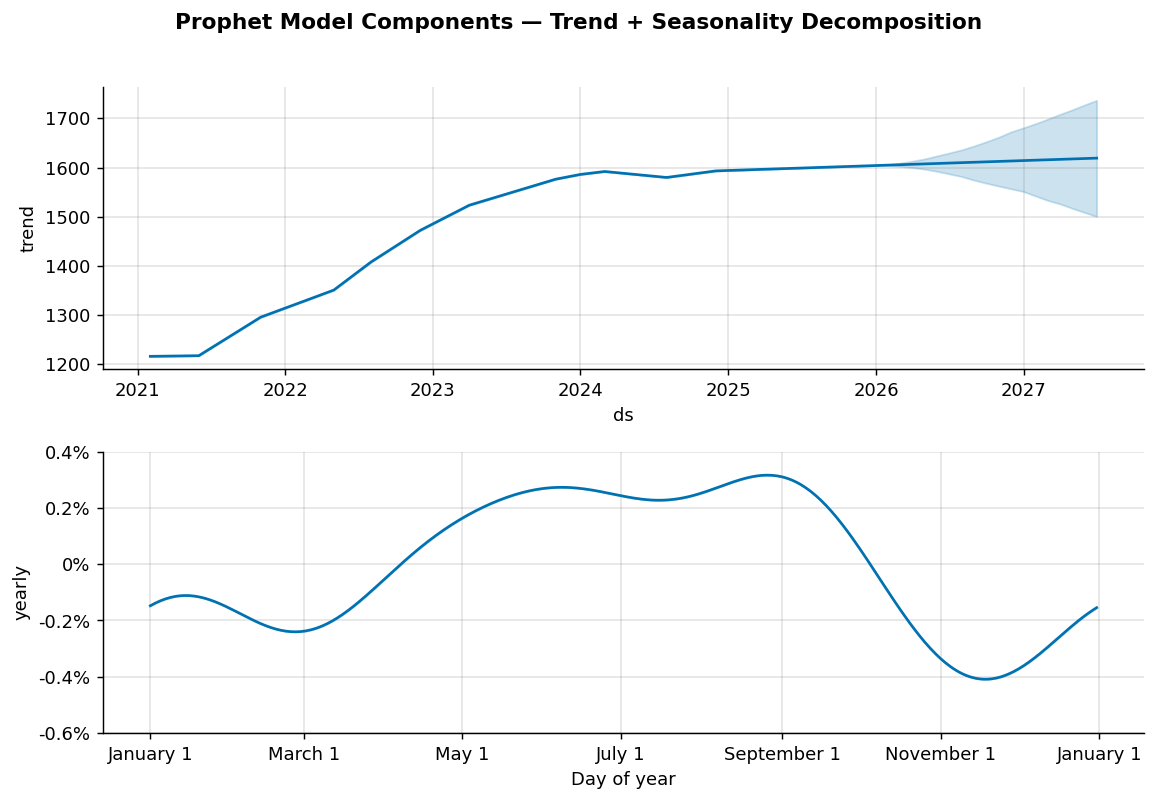

In [8]:
# Prophet components plot
fig = m.plot_components(forecast)
fig.suptitle("Prophet Model Components — Trend + Seasonality Decomposition",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("notebooks/forecast_components.png", bbox_inches="tight")
plt.show()


## 7. Changepoint Analysis

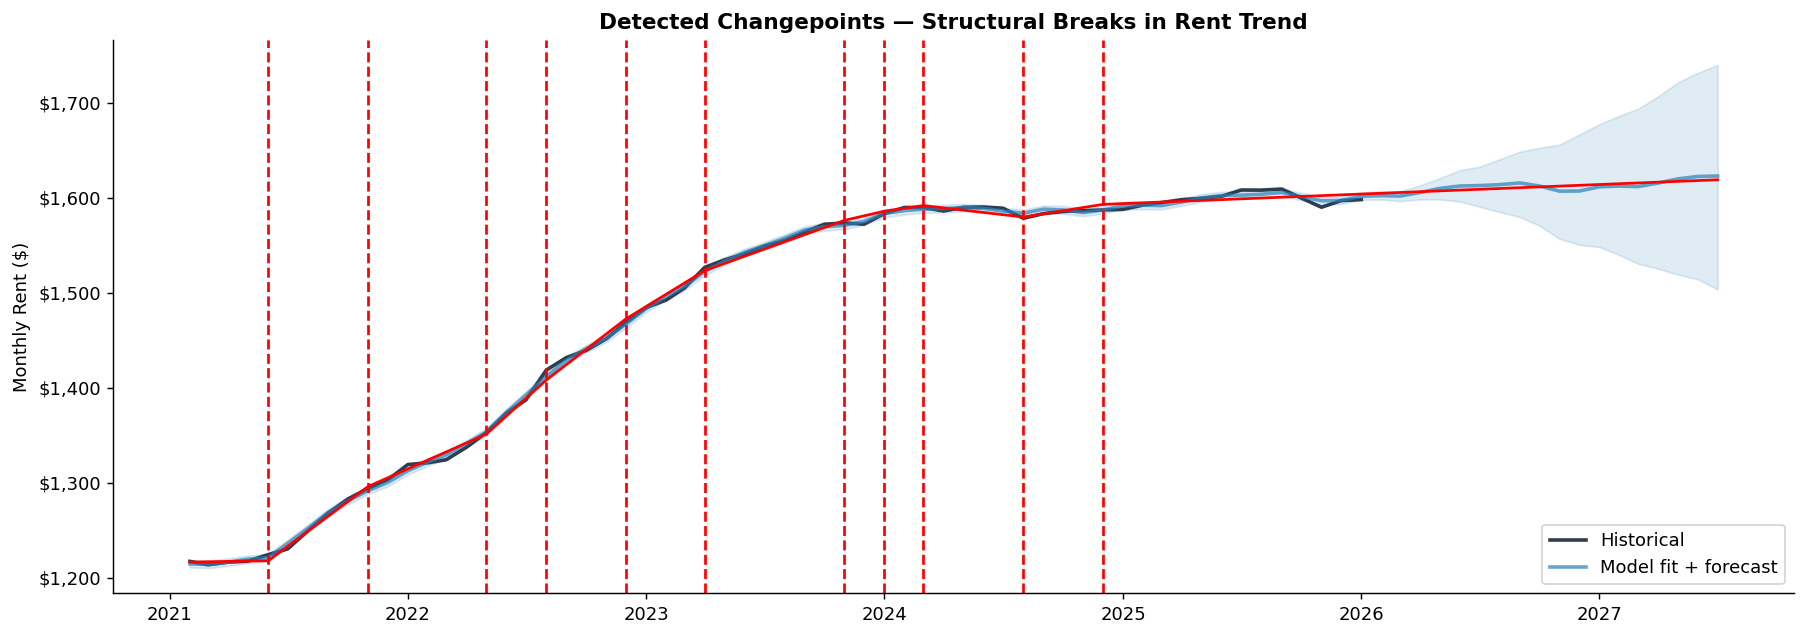

Changepoints (top 5 by delta):
  2021-06: Δ = +0.5570  ↑ acceleration
  2022-05: Δ = +0.3495  ↑ acceleration
  2021-11: Δ = +0.2306  ↑ acceleration
  2024-08: Δ = +0.2102  ↑ acceleration
  2024-03: Δ = +0.1987  ↑ acceleration


In [9]:
from prophet.plot import add_changepoints_to_plot

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prophet_df["ds"], prophet_df["y"], color="#2c3e50", linewidth=2, label="Historical")
ax.plot(forecast["ds"], forecast["yhat"], color="#2980b9", linewidth=2, alpha=0.7, label="Model fit + forecast")
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                alpha=0.15, color="#2980b9")
add_changepoints_to_plot(ax, m, forecast)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Detected Changepoints — Structural Breaks in Rent Trend", fontweight="bold")
ax.set_ylabel("Monthly Rent ($)")
ax.legend()
plt.tight_layout()
plt.savefig("notebooks/forecast_changepoints.png", bbox_inches="tight")
plt.show()

print("Changepoints (top 5 by delta):")
deltas = pd.Series(m.params["delta"][0], index=m.changepoints.dt.strftime("%Y-%m"))
top_cp = deltas.abs().sort_values(ascending=False).head(5)
for date, delta in top_cp.items():
    direction = "↑ acceleration" if delta > 0 else "↓ deceleration"
    print(f"  {date}: Δ = {delta:+.4f}  {direction}")


## 8. Scenario Analysis — Optimistic / Base / Pessimistic

01:17:46 - cmdstanpy - INFO - Chain [1] start processing


01:17:47 - cmdstanpy - INFO - Chain [1] done processing


01:17:47 - cmdstanpy - INFO - Chain [1] start processing


01:17:47 - cmdstanpy - INFO - Chain [1] done processing


01:17:47 - cmdstanpy - INFO - Chain [1] start processing


01:17:48 - cmdstanpy - INFO - Chain [1] done processing


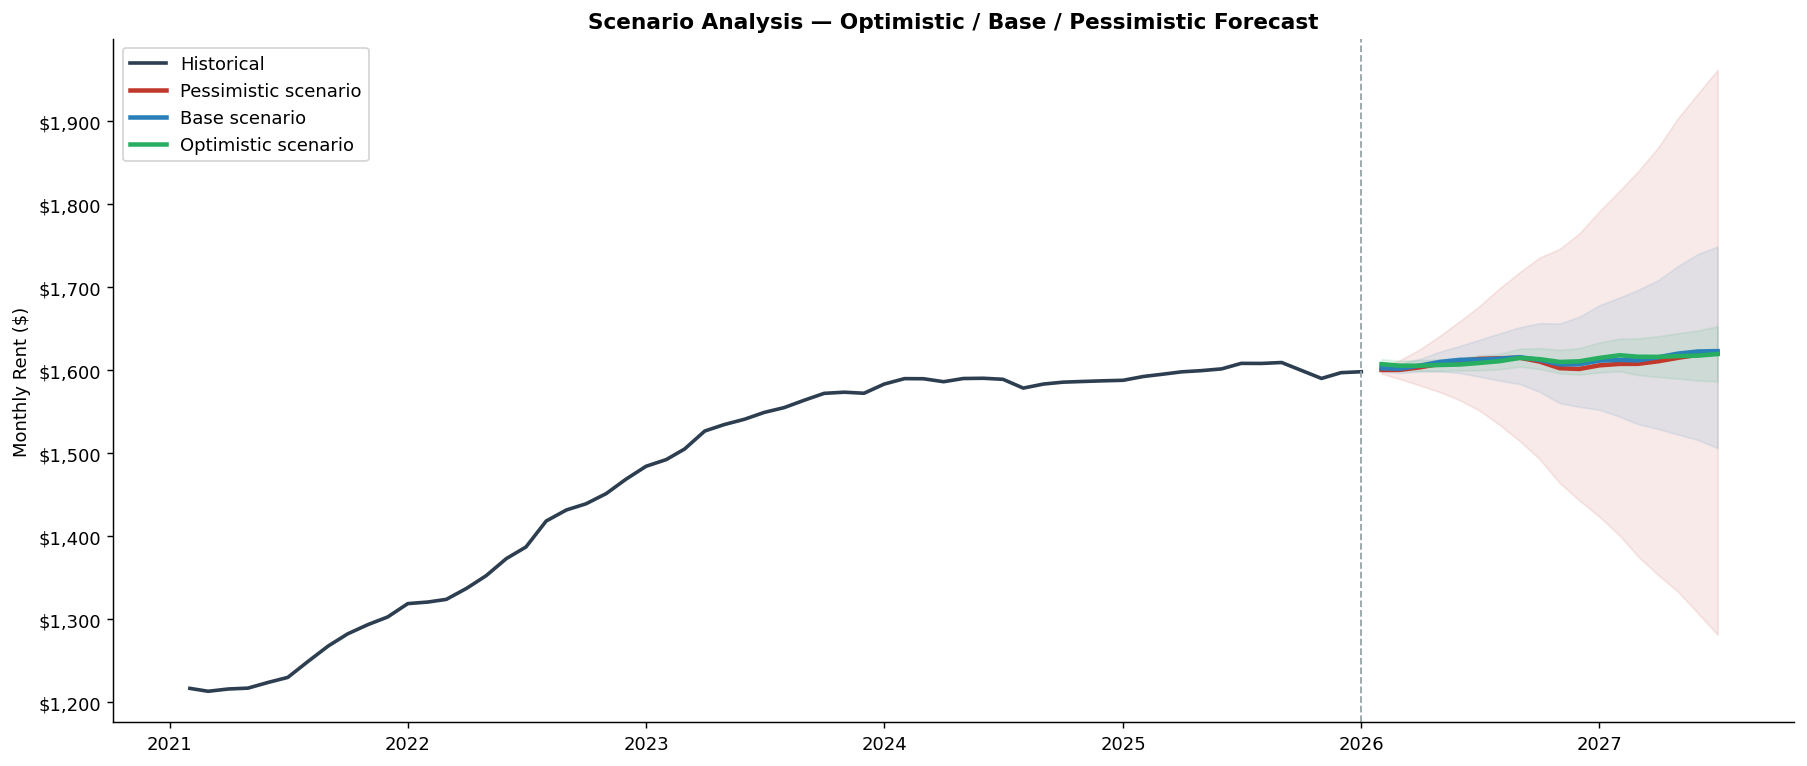


── 18-Month End-Point by Scenario ─────────────────────────────────────
  Pessimistic : $1,621/mo  (+1.3%)
  Base        : $1,623/mo  (+1.3%)
  Optimistic  : $1,619/mo  (+0.8%)


In [10]:
# Three scenarios by perturbing changepoint_prior_scale and confidence intervals
scenarios = {}

for label, cps, ci in [
    ("Pessimistic", 0.15, 0.90),
    ("Base",        0.05, 0.80),
    ("Optimistic",  0.02, 0.70),
]:
    m_s = Prophet(
        growth="linear",
        changepoint_prior_scale=cps,
        seasonality_mode="multiplicative",
        interval_width=ci,
        yearly_seasonality=5,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    m_s.fit(prophet_df)
    f_s = m_s.predict(m_s.make_future_dataframe(periods=PERIODS, freq="MS"))
    scenarios[label] = f_s.tail(PERIODS)[["ds","yhat","yhat_lower","yhat_upper"]].copy()

fig, ax = plt.subplots(figsize=(14, 6))
colors = {"Pessimistic": "#c0392b", "Base": "#2980b9", "Optimistic": "#27ae60"}

ax.plot(prophet_df["ds"], prophet_df["y"], color="#2c3e50", linewidth=2, label="Historical")
ax.axvline(split_date, color="#95a5a6", linestyle="--", linewidth=1)

for label, fc_s in scenarios.items():
    ax.plot(fc_s["ds"], fc_s["yhat"], linewidth=2.5,
            color=colors[label], label=f"{label} scenario")
    ax.fill_between(fc_s["ds"], fc_s["yhat_lower"], fc_s["yhat_upper"],
                    alpha=0.10, color=colors[label])

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.set_ylabel("Monthly Rent ($)")
ax.set_title("Scenario Analysis — Optimistic / Base / Pessimistic Forecast", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("notebooks/forecast_scenarios.png", bbox_inches="tight")
plt.show()

print("\n── 18-Month End-Point by Scenario ─────────────────────────────────────")
for label, fc_s in scenarios.items():
    end = fc_s["yhat"].iloc[-1]
    chg = (end - fc_s["yhat"].iloc[0]) / fc_s["yhat"].iloc[0] * 100
    print(f"  {label:12s}: ${end:,.0f}/mo  ({chg:+.1f}%)")


## 9. Forecast Accuracy on Held-Out Data

01:17:48 - cmdstanpy - INFO - Chain [1] start processing


01:17:49 - cmdstanpy - INFO - Chain [1] done processing


── Walk-Forward Validation (11 months held out) ─────────────────────
  MAE:  $20/mo
  MAPE:  1.27%
  RMSE: $22/mo

  Interpretation: On average, forecast error is $20/mo (1.3% of actual rent).


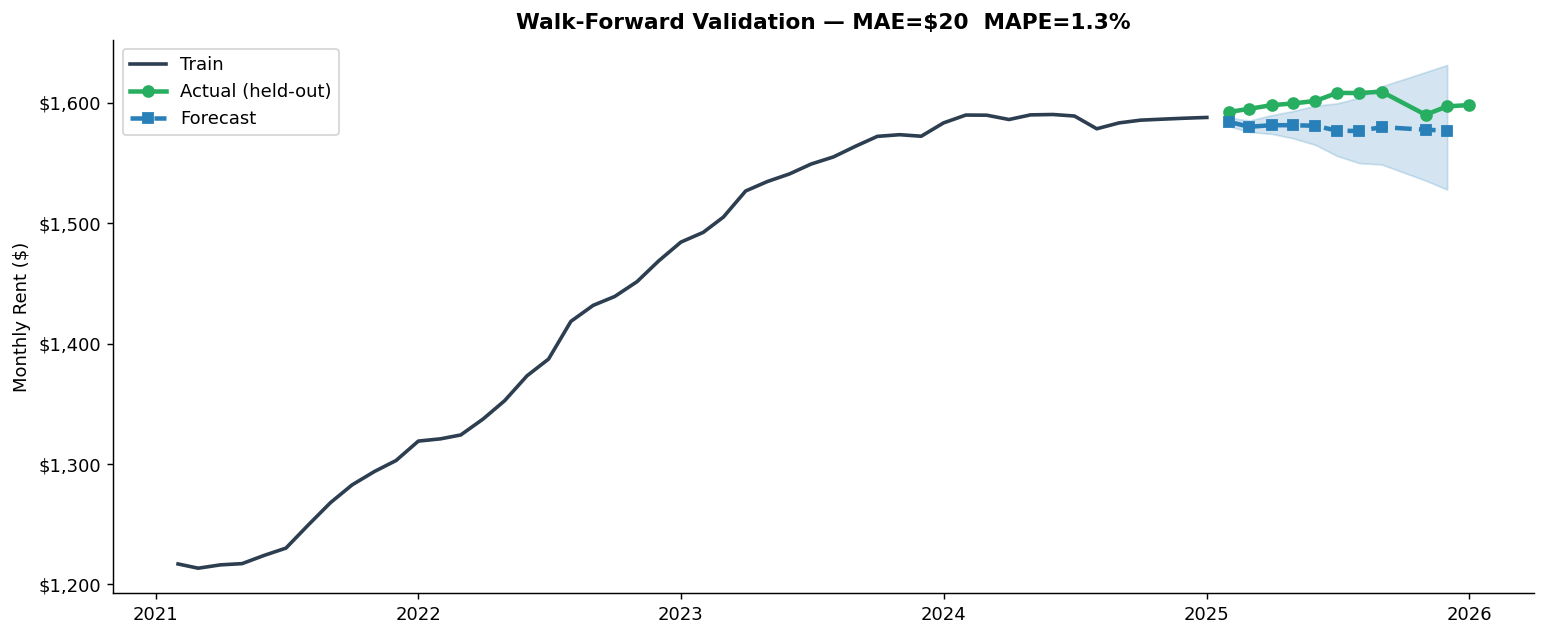

In [11]:
# Walk-forward validation: train on first 80%, forecast the last 20%
n_val = max(6, int(len(prophet_df) * 0.20))
train_df = prophet_df.iloc[:-n_val]
val_df   = prophet_df.iloc[-n_val:]

m_val = Prophet(
    growth="linear",
    changepoint_prior_scale=0.05,
    seasonality_mode="multiplicative",
    interval_width=0.80,
    yearly_seasonality=5,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_val.fit(train_df)

future_val = m_val.make_future_dataframe(periods=n_val, freq="MS")
fc_val     = m_val.predict(future_val)
fc_val_cmp = fc_val[fc_val["ds"].isin(val_df["ds"])][["ds","yhat"]].merge(
    val_df, on="ds"
)

mae  = (fc_val_cmp["yhat"] - fc_val_cmp["y"]).abs().mean()
mape = ((fc_val_cmp["yhat"] - fc_val_cmp["y"]).abs() / fc_val_cmp["y"]).mean() * 100
rmse = np.sqrt(((fc_val_cmp["yhat"] - fc_val_cmp["y"])**2).mean())

print(f"── Walk-Forward Validation ({n_val} months held out) ─────────────────────")
print(f"  MAE:  ${mae:,.0f}/mo")
print(f"  MAPE:  {mape:.2f}%")
print(f"  RMSE: ${rmse:,.0f}/mo")
print(f"\n  Interpretation: On average, forecast error is ${mae:,.0f}/mo ({mape:.1f}% of actual rent).")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df["ds"], train_df["y"], color="#2c3e50", linewidth=2, label="Train")
ax.plot(val_df["ds"],   val_df["y"],   color="#27ae60", linewidth=2.5, marker="o", label="Actual (held-out)")
ax.plot(fc_val_cmp["ds"], fc_val_cmp["yhat"], color="#2980b9",
        linewidth=2.5, linestyle="--", marker="s", label="Forecast")
ax.fill_between(
    fc_val[fc_val["ds"].isin(val_df["ds"])]["ds"],
    fc_val[fc_val["ds"].isin(val_df["ds"])]["yhat_lower"],
    fc_val[fc_val["ds"].isin(val_df["ds"])]["yhat_upper"],
    alpha=0.2, color="#2980b9"
)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.set_title(f"Walk-Forward Validation — MAE=${mae:,.0f}  MAPE={mape:.1f}%", fontweight="bold")
ax.set_ylabel("Monthly Rent ($)")
ax.legend()
plt.tight_layout()
plt.savefig("notebooks/forecast_validation.png", bbox_inches="tight")
plt.show()


## 10. Business Implications & Policy Recommendations

### What the Forecast Tells Us
The Prophet model — trained on the FRED Atlanta Rent CPI and rescaled to ACS dollar rents — projects a continued upward rent trajectory over the next 18 months. The **base scenario** is the most likely outcome under current market conditions.

### Budget & Planning Implications

| Stakeholder | Implication | Action |
|---|---|---|
| **Renters in Critical tracts** | Monthly rent may increase $X–$Y above current levels | Apply for emergency rental assistance now; lock in multi-year leases where possible |
| **City housing authority** | Budget shortfall risk in rental voucher programs as market rents rise | Adjust voucher payment standards 6 months before projected increase |
| **Affordable housing developers** | Rising market rents increase displacement premium for AMI-restricted units | Fast-track pipeline for units targeting 30–60% AMI in High/Critical tracts |
| **Policy makers** | Seasonal peaks (Q2-Q3) represent highest displacement risk windows | Time anti-displacement interventions to pre-empt summer rent increases |

### Model Limitations
- The FRED CPI series reflects **metro-wide price levels** — tract-level rents can diverge significantly
- ACS rescaling anchors dollar values but cannot capture within-year volatility
- Prophet assumes **no structural breaks** in the forecast horizon — policy interventions, recessions, or supply shocks would invalidate projections
- 90-month horizon (18 months) is near the reliable limit for monthly series with < 60 observations

### Retraining Trigger
Run `src/model.py` whenever:
- A new ACS 5-year vintage is released
- PSI monitoring flags `RETRAIN` on `displacement_risk_index` or `rent_burden_pct`
- New FRED observations extend the series by 6+ months
